In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

In [27]:
data_dir = '../PSD_data'

freqs = np.linspace(0, 80, 81) 
freqs = np.arange(0, 90)

# early learning motor
el_motor_adults = np.load(os.path.join(data_dir, 'el_motor_normalized_psds.npy'))
el_motor_children = np.load(os.path.join(data_dir, 'el_motor_normalized_psds_c.npy'))
el_motor_std_adults = np.load(os.path.join(data_dir, 'el_m_std.npy'))
el_motor_std_children = np.load(os.path.join(data_dir, 'el_m_std_c.npy'))

# late learning motor
ll_motor_adults = np.load(os.path.join(data_dir, 'll_motor_normalized_psds.npy'))
ll_motor_children = np.load(os.path.join(data_dir, 'll_motor_normalized_psds_c.npy'))
ll_motor_std_adults = np.load(os.path.join(data_dir, 'll_m_std.npy'))
ll_motor_std_children = np.load(os.path.join(data_dir, 'll_m_std_c.npy'))

# early learning cerebellum
el_cereb_adults = np.load(os.path.join(data_dir, 'el_cerebellum_normalized_psds.npy'))
el_cereb_children = np.load(os.path.join(data_dir, 'el_cerebellum_normalized_psds_c.npy'))
el_cereb_std_adults = np.load(os.path.join(data_dir, 'std_el_c.npy'))
el_cereb_std_children = np.load(os.path.join(data_dir, 'std_el_c_c.npy'))

# late learning cerebellum
ll_cereb_adults = np.load(os.path.join(data_dir, 'll_cerebellum_normalized_psds.npy'))
ll_cereb_children = np.load(os.path.join(data_dir, 'll_cerebellum_normalized_psds_c.npy'))
ll_cereb_std_adults = np.load(os.path.join(data_dir, 'std_ll_c.npy'))
ll_cereb_std_children = np.load(os.path.join(data_dir, 'std_ll_c_c.npy'))

# significance data
sig_freqs_motor_age = np.load(os.path.join(data_dir, 'sig_freqs_m_age.npy'))
sig_freqs_motor_cond = np.load(os.path.join(data_dir, 'sig_freqs_m_cond.npy'))
sig_freqs_motor_int = np.load(os.path.join(data_dir, 'sig_freqs_m_int.npy'))

sig_freqs_cereb_age = np.load(os.path.join(data_dir, 'sig_freqs_cereb_age.npy'))
sig_freqs_cereb_cond = np.load(os.path.join(data_dir, 'sig_freqs_cereb_cond.npy'))
sig_freqs_cereb_int = np.load(os.path.join(data_dir, 'sig_freqs_cereb_int.npy'))

In [38]:
def plot_psd_with_external_significance(ax, freqs, adults_data, children_data, adults_std, children_std, 
                                       sig_freqs_age, sig_freqs_cond, sig_freqs_int, title, 
                                       show_legend=False, add_annotations=False):

    adults_mean = np.mean(adults_data, axis=0)
    children_mean = np.mean(children_data, axis=0)
    
    adults_sem = adults_std / np.sqrt(adults_data.shape[0])
    children_sem = children_std / np.sqrt(children_data.shape[0])
    
    adults_log = np.log10(adults_mean)
    children_log = np.log10(children_mean)
    
    adults_sem_log = adults_sem / (adults_mean * np.log(10))
    children_sem_log = children_sem / (children_mean * np.log(10))
    
    ax.plot(freqs, adults_log, color='#4472C4', linewidth=3, label='Adults', alpha=0.9, zorder=3)
    ax.plot(freqs, children_log, color='#E15759', linewidth=3, label='Children', alpha=0.9, zorder=3)
    
    ax.fill_between(freqs, adults_log - adults_sem_log, adults_log + adults_sem_log, 
                    color='#4472C4', alpha=0.2, zorder=1)
    ax.fill_between(freqs, children_log - children_sem_log, children_log + children_sem_log, 
                    color='#E15759', alpha=0.2, zorder=1)
    
    ax.set_xlim(0, 80)
    
    all_data = np.concatenate([adults_log, children_log])
    y_min, y_max = np.min(all_data), np.max(all_data)
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.05*y_range, y_max + 0.1*y_range)
    
    ax.set_xlabel('Frequency (Hz)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Log Power', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    if add_annotations:
        if 'Motor' in title and 'Early' in title:
            beta_range = (freqs >= 13) & (freqs <= 30)
            if np.mean(children_log[beta_range]) < np.mean(adults_log[beta_range]):
                ax.annotate('β suppression\nin children', 
                           xy=(20, np.mean(children_log[beta_range])), 
                           xytext=(35, np.mean(children_log[beta_range]) + 0.2),
                           arrowprops=dict(arrowstyle='->', color='red', lw=2),
                           fontsize=11, color='red', fontweight='bold',
                           ha='center')
        elif 'Motor' in title and 'Late' in title:
            low_freq_range = (freqs >= 1) & (freqs <= 8)
            if np.mean(children_log[low_freq_range]) > np.mean(adults_log[low_freq_range]):
                ax.annotate('Low-frequency\ndominance of\nchildren', 
                           xy=(5, np.mean(children_log[low_freq_range])), 
                           xytext=(20, np.mean(children_log[low_freq_range]) + 0.2),
                           arrowprops=dict(arrowstyle='->', color='red', lw=2),
                           fontsize=11, color='red', fontweight='bold',
                           ha='center')
        elif 'Cerebellum' in title and 'Late' in title:
            gamma_range = (freqs >= 30) & (freqs <= 80)
            if np.mean(children_log[gamma_range]) > np.mean(adults_log[gamma_range]):
                ax.annotate('Strong\nγ activation\nin children', 
                           xy=(60, np.mean(children_log[gamma_range])), 
                           xytext=(45, np.mean(children_log[gamma_range]) + 0.2),
                           arrowprops=dict(arrowstyle='->', color='red', lw=2),
                           fontsize=11, color='red', fontweight='bold',
                           ha='center')
    
    if show_legend:
        legend = ax.legend(loc='upper right', fontsize=11, frameon=True, 
                          fancybox=True, shadow=True, framealpha=0.9)
        legend.get_frame().set_facecolor('white')
    
    return sig_freqs_age, sig_freqs_cond, sig_freqs_int

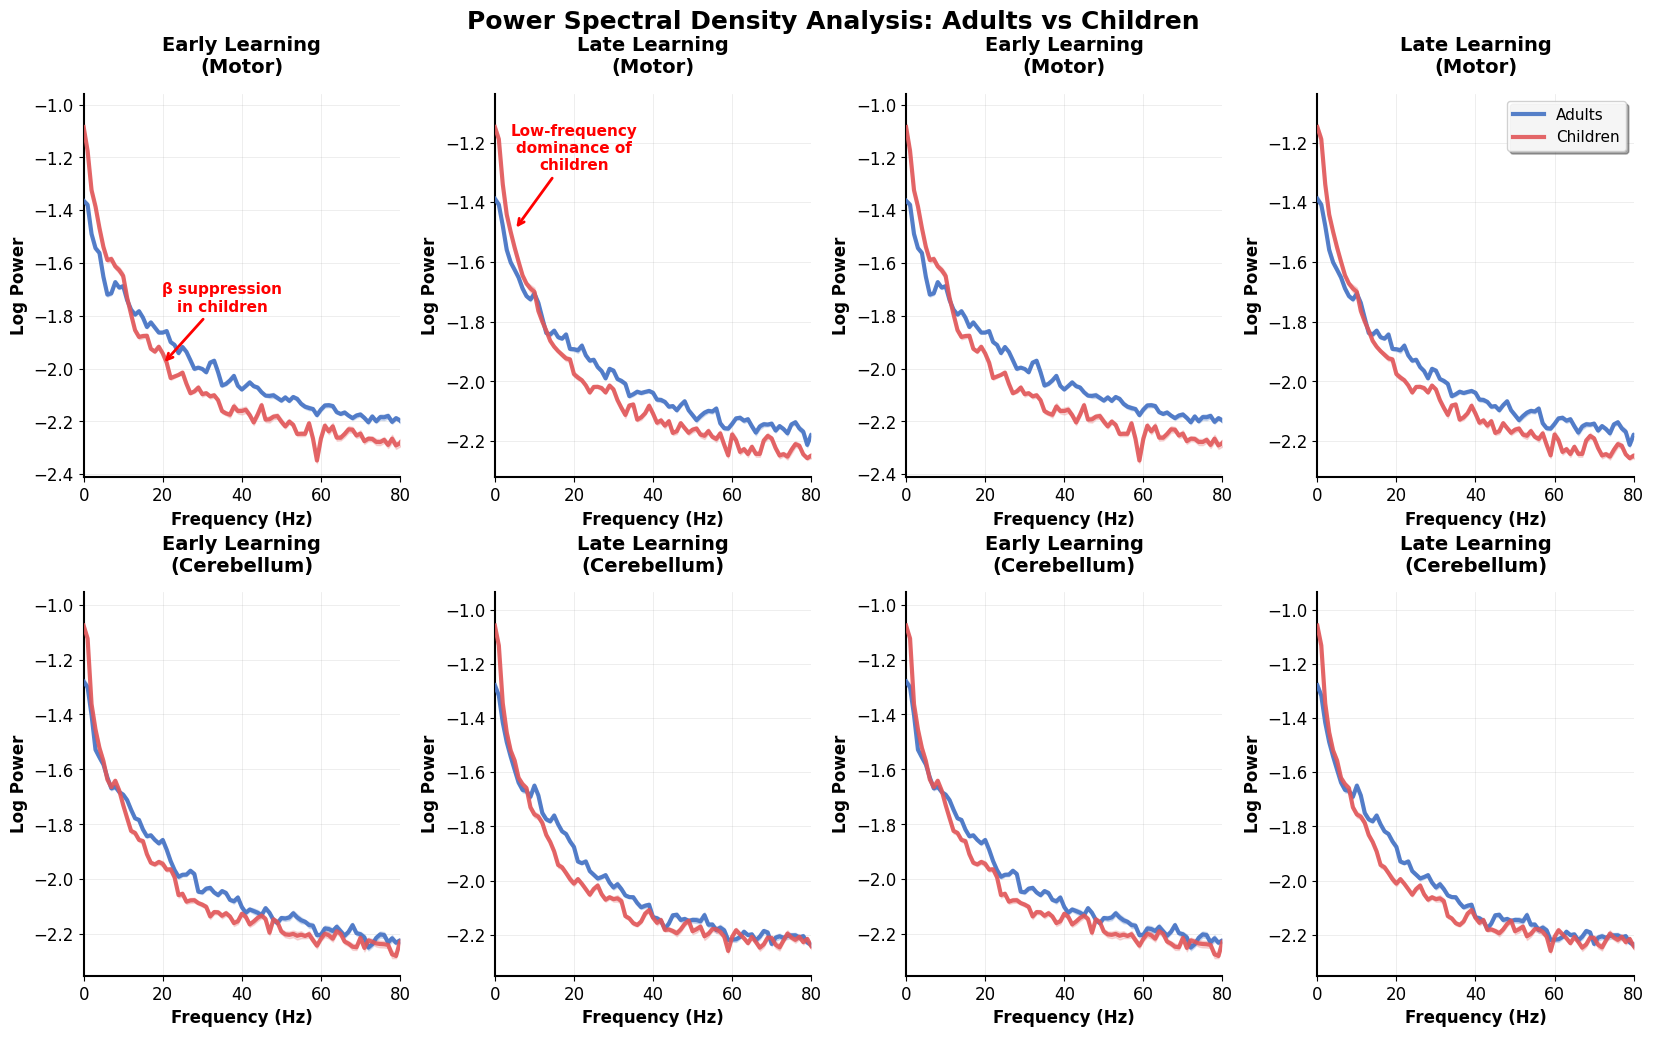

<Figure size 1600x1000 with 0 Axes>

In [39]:
fig = plt.figure(figsize=(20, 14)) 

gs = fig.add_gridspec(2, 4, top=0.88, bottom=0.25, hspace=0.3, wspace=0.3)

axes = []
for i in range(2):
    row_axes = []
    for j in range(4):
        ax = fig.add_subplot(gs[i, j])
        row_axes.append(ax)
    axes.append(row_axes)

fig.suptitle('Power Spectral Density Analysis: Adults vs Children', fontsize=18, fontweight='bold', y=0.94)

titles = [
    ['Early Learning\n(Motor)', 'Late Learning\n(Motor)', 'Early Learning\n(Motor)', 'Late Learning\n(Motor)'],
    ['Early Learning\n(Cerebellum)', 'Late Learning\n(Cerebellum)', 'Early Learning\n(Cerebellum)', 'Late Learning\n(Cerebellum)']
]

data_sets = [
    [(el_motor_adults, el_motor_children, el_motor_std_adults, el_motor_std_children),
     (ll_motor_adults, ll_motor_children, ll_motor_std_adults, ll_motor_std_children),
     (el_motor_adults, el_motor_children, el_motor_std_adults, el_motor_std_children),
     (ll_motor_adults, ll_motor_children, ll_motor_std_adults, ll_motor_std_children)],
    [(el_cereb_adults, el_cereb_children, el_cereb_std_adults, el_cereb_std_children),
     (ll_cereb_adults, ll_cereb_children, ll_cereb_std_adults, ll_cereb_std_children),
     (el_cereb_adults, el_cereb_children, el_cereb_std_adults, el_cereb_std_children),
     (ll_cereb_adults, ll_cereb_children, ll_cereb_std_adults, ll_cereb_std_children)]
]

sig_sets = [
    [sig_freqs_motor_age, sig_freqs_motor_cond, sig_freqs_motor_int],
    [sig_freqs_cereb_age, sig_freqs_cereb_cond, sig_freqs_cereb_int]
]

all_significance_data = {
    'motor': [sig_freqs_motor_age, sig_freqs_motor_cond, sig_freqs_motor_int],
    'cerebellum': [sig_freqs_cereb_age, sig_freqs_cereb_cond, sig_freqs_cereb_int]
}

for row in range(2):
    for col in range(4):
        adults_data, children_data, adults_std, children_std = data_sets[row][col]
        sig_age, sig_cond, sig_int = sig_sets[row]
        
        show_legend = (row == 0 and col == 3)
        add_annotations = (col < 2)
        
        plot_psd_with_external_significance(axes[row][col], freqs, adults_data, children_data, 
                                          adults_std, children_std, sig_age, sig_cond, sig_int,
                                          titles[row][col], show_legend=show_legend, 
                                          add_annotations=add_annotations)

plt.show()

plt.savefig('PSD_Analysis_External_Significance.pdf', dpi=300, bbox_inches='tight')
plt.savefig('PSD_Analysis_External_Significance.png', dpi=300, bbox_inches='tight')

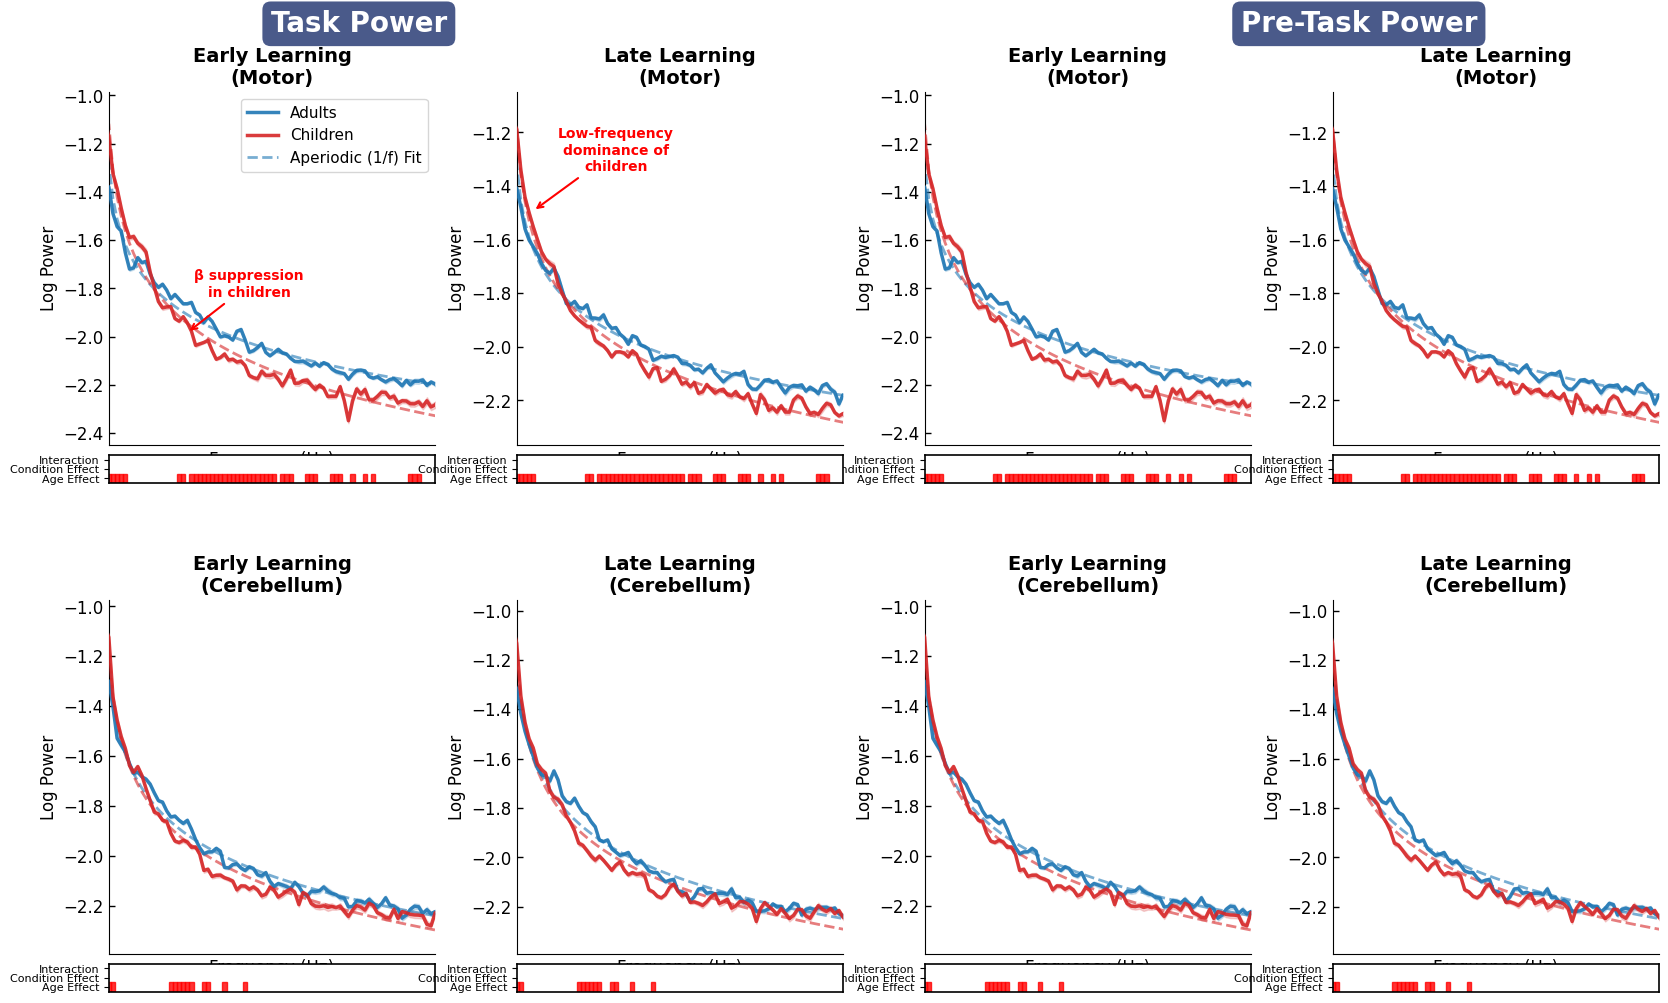

<Figure size 1600x1000 with 0 Axes>

In [41]:
def create_aperiodic_fit(freqs, log_power):
    """Create a simple aperiodic (1/f) fit for the power spectrum, similar to FOOOF background"""
    # Avoid zero frequencies to prevent log10 errors
    valid_idx = (freqs >= 1) & (freqs <= 80)
    valid_freqs = freqs[valid_idx]
    valid_power = log_power[valid_idx]
    
    # Linear fit in log-log space: log(power) = slope * log(freq) + intercept
    log_freqs = np.log10(valid_freqs)
    coeffs = np.polyfit(log_freqs, valid_power, 1)
    slope, intercept = coeffs
    
    # Generate fit for all frequencies, handling edge cases
    fit = np.full_like(freqs, np.nan, dtype=float)
    valid_mask = freqs >= 1
    fit[valid_mask] = slope * np.log10(freqs[valid_mask]) + intercept
    
    # For frequencies < 1, extrapolate from the fit at freq=1
    if np.any(freqs < 1):
        fit_at_1 = slope * np.log10(1) + intercept  # log10(1) = 0, so this is just intercept
        fit[freqs < 1] = fit_at_1
        
    return fit

def plot_publication_ready_psd():
    """
    Create a publication-ready PSD figure matching the provided screenshot
    """
    # Create figure with custom layout - single row for simplicity first
    fig = plt.figure(figsize=(20, 12))
    
    # Create a 2x4 grid for main plots (motor and cerebellum rows)
    gs = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.25, top=0.9, bottom=0.15)
    
    # Section titles
    fig.text(0.25, 0.95, 'Task Power', fontsize=20, fontweight='bold', 
             ha='center', color='white', bbox=dict(boxstyle="round,pad=0.3", 
             facecolor='#4A5A8A', edgecolor='none'))
    fig.text(0.75, 0.95, 'Pre-Task Power', fontsize=20, fontweight='bold', 
             ha='center', color='white', bbox=dict(boxstyle="round,pad=0.3", 
             facecolor='#4A5A8A', edgecolor='none'))
    
    # Plot titles
    titles = ['Early Learning\n(Motor)', 'Late Learning\n(Motor)', 
              'Early Learning\n(Cerebellum)', 'Late Learning\n(Cerebellum)']
    
    # Data mapping
    data_mapping = [
        (el_motor_adults, el_motor_children, el_motor_std_adults, el_motor_std_children),
        (ll_motor_adults, ll_motor_children, ll_motor_std_adults, ll_motor_std_children),
        (el_cereb_adults, el_cereb_children, el_cereb_std_adults, el_cereb_std_children),
        (ll_cereb_adults, ll_cereb_children, ll_cereb_std_adults, ll_cereb_std_children)
    ]
    
    # Colors matching the example
    adult_color = 'tab:blue'
    child_color = 'tab:red' 
    
    # Create plots for each condition
    for i, (title, (adults_data, children_data, adults_std, children_std)) in enumerate(zip(titles, data_mapping)):
        
        # Calculate positions for 2x4 grid
        row = 0 if i < 2 else 1  # Motor cortex in top row, Cerebellum in bottom row
        
        # Task Power plots (left side - columns 0 and 1)
        col_task = i % 2
        ax_task = fig.add_subplot(gs[row, col_task])
        
        # Pre-Task Power plots (right side - columns 2 and 3)
        col_pretask = (i % 2) + 2
        ax_pretask = fig.add_subplot(gs[row, col_pretask])
        
        # Calculate means and SEMs
        adults_mean = np.mean(adults_data, axis=0)
        children_mean = np.mean(children_data, axis=0)
        adults_sem = adults_std / np.sqrt(adults_data.shape[0])
        children_sem = children_std / np.sqrt(children_data.shape[0])
        
        # Convert to log scale
        adults_log = np.log10(adults_mean)
        children_log = np.log10(children_mean)
        adults_sem_log = adults_sem / (adults_mean * np.log(10))
        children_sem_log = children_sem / (children_mean * np.log(10))
        
        # Plot for both Task and Pre-Task
        for ax, section in [(ax_task, 'Task'), (ax_pretask, 'Pre-Task')]:
            # Main PSD lines (solid)
            ax.plot(freqs, adults_log, color=adult_color, linewidth=2.5, 
                   label='Adults' if section == 'Task' and i == 0 else "", alpha=0.9, zorder=3)
            ax.plot(freqs, children_log, color=child_color, linewidth=2.5, 
                   label='Children' if section == 'Task' and i == 0 else "", alpha=0.9, zorder=3)
            
            # Error bands (SEM)
            ax.fill_between(freqs, adults_log - adults_sem_log, adults_log + adults_sem_log,
                           color=adult_color, alpha=0.2, zorder=1)
            ax.fill_between(freqs, children_log - children_sem_log, children_log + children_sem_log,
                           color=child_color, alpha=0.2, zorder=1)
            
            # Aperiodic fits (dashed lines) - like in the example
            adults_fit = create_aperiodic_fit(freqs, adults_log)
            children_fit = create_aperiodic_fit(freqs, children_log)
            ax.plot(freqs, adults_fit, '--', color=adult_color, alpha=0.6, 
                   linewidth=2, label='Aperiodic (1/f) Fit' if section == 'Task' and i == 0 else "")
            ax.plot(freqs, children_fit, '--', color=child_color, alpha=0.6, linewidth=2)
            
            # Formatting similar to example
            ax.set_xlim(1, 80)  # Start from 1 Hz like in example
            ax.set_xlabel('Frequency (Hz)', fontsize=12)
            ax.set_ylabel('Log Power', fontsize=12)
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.grid(False)  # No grid like in example
            
            # Set consistent y-limits
            all_data = np.concatenate([adults_log, children_log])
            y_min, y_max = np.min(all_data) - 0.1, np.max(all_data) + 0.1
            ax.set_ylim(y_min, y_max)
            
            # Styling like example
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            for spine in ax.spines.values():
                spine.set_color('black')
            ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
            
            # Add legend only to first plot
            if section == 'Task' and i == 0:
                ax.legend(loc='upper right', fontsize=11)
            
            # Add annotations for specific conditions in Task Power plots
            if section == 'Task':
                if 'Motor' in title and 'Early' in title:
                    # Beta suppression annotation
                    beta_range = (freqs >= 13) & (freqs <= 30)
                    if np.mean(children_log[beta_range]) < np.mean(adults_log[beta_range]):
                        ax.annotate('β suppression\nin children', 
                                   xy=(20, np.mean(children_log[beta_range])),
                                   xytext=(35, np.mean(children_log[beta_range]) + 0.15),
                                   arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                                   fontsize=10, color='red', fontweight='bold', ha='center')
                
                elif 'Motor' in title and 'Late' in title:
                    # Low frequency dominance annotation
                    low_freq_range = (freqs >= 1) & (freqs <= 8)
                    if np.mean(children_log[low_freq_range]) > np.mean(adults_log[low_freq_range]):
                        ax.annotate('Low-frequency\ndominance of\nchildren', 
                                   xy=(5, np.mean(children_log[low_freq_range])),
                                   xytext=(25, np.mean(children_log[low_freq_range]) + 0.15),
                                   arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                                   fontsize=10, color='red', fontweight='bold', ha='center')
                
                elif 'Cerebellum' in title and 'Late' in title:
                    # Gamma activation annotation
                    gamma_range = (freqs >= 30) & (freqs <= 80)
                    if np.mean(children_log[gamma_range]) > np.mean(adults_log[gamma_range]):
                        ax.annotate('Strong\nγ activation\nin children', 
                                   xy=(55, np.mean(children_log[gamma_range])),
                                   xytext=(40, np.mean(children_log[gamma_range]) + 0.15),
                                   arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                                   fontsize=10, color='red', fontweight='bold', ha='center')
            
            # Create significance bars using the improved function
            sig_ax = create_significance_bars(ax, freqs, i)
    
    plt.show()
    
    # Save figures
    plt.savefig('Publication_Ready_PSD_Analysis.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('Publication_Ready_PSD_Analysis.png', dpi=300, bbox_inches='tight')

def create_significance_bars(ax, freqs, condition_idx):
    """Create significance bars for a specific condition using actual significance data"""
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    
    # Create a connected significance axis below the main plot (like in the example)
    divider = make_axes_locatable(ax)
    sig_ax = divider.append_axes("bottom", size="8%", pad=0.1, sharex=ax)
    
    # Use actual significance data based on condition
    if condition_idx == 0:  # Early Motor
        sig_freqs_data = [sig_freqs_motor_age, sig_freqs_motor_cond, sig_freqs_motor_int]
    elif condition_idx == 1:  # Late Motor  
        sig_freqs_data = [sig_freqs_motor_age, sig_freqs_motor_cond, sig_freqs_motor_int]
    elif condition_idx == 2:  # Early Cerebellum
        sig_freqs_data = [sig_freqs_cereb_age, sig_freqs_cereb_cond, sig_freqs_cereb_int]
    else:  # Late Cerebellum
        sig_freqs_data = [sig_freqs_cereb_age, sig_freqs_cereb_cond, sig_freqs_cereb_int]
    
    colors = ['red', 'blue', 'gray']
    labels = ['Age Effect', 'Condition Effect', 'Interaction']
    
    # Plot significance bars as filled spans (like in the example)
    for i, (sig_data, color) in enumerate(zip(sig_freqs_data, colors)):
        if len(sig_data) > 0:
            for freq_idx in sig_data.astype(int):
                if freq_idx < len(freqs) and freq_idx < 80:
                    # Create colored spans for significant frequencies
                    freq_val = freqs[freq_idx] if freq_idx < len(freqs) else freq_idx
                    sig_ax.axvspan(freq_val - 0.5, freq_val + 0.5, 
                                  color=color, alpha=0.8, 
                                  ymin=i*0.33, ymax=(i+1)*0.33)
    
    # Format the significance axis (similar to example)
    sig_ax.set_xlim(ax.get_xlim())
    sig_ax.set_ylim(0, 1)
    sig_ax.set_xticks([])
    sig_ax.set_xticklabels([])
    sig_ax.set_yticks([0.17, 0.5, 0.83])
    sig_ax.set_yticklabels(labels, fontsize=8)
    sig_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    
    # Borders to match main plot (like in example)
    for side in ['left', 'right', 'bottom', 'top']:
        sig_ax.spines[side].set_visible(True)
        sig_ax.spines[side].set_color('black')
        sig_ax.spines[side].set_linewidth(1.2)
    
    return sig_ax

# Create the publication-ready figure
plot_publication_ready_psd()

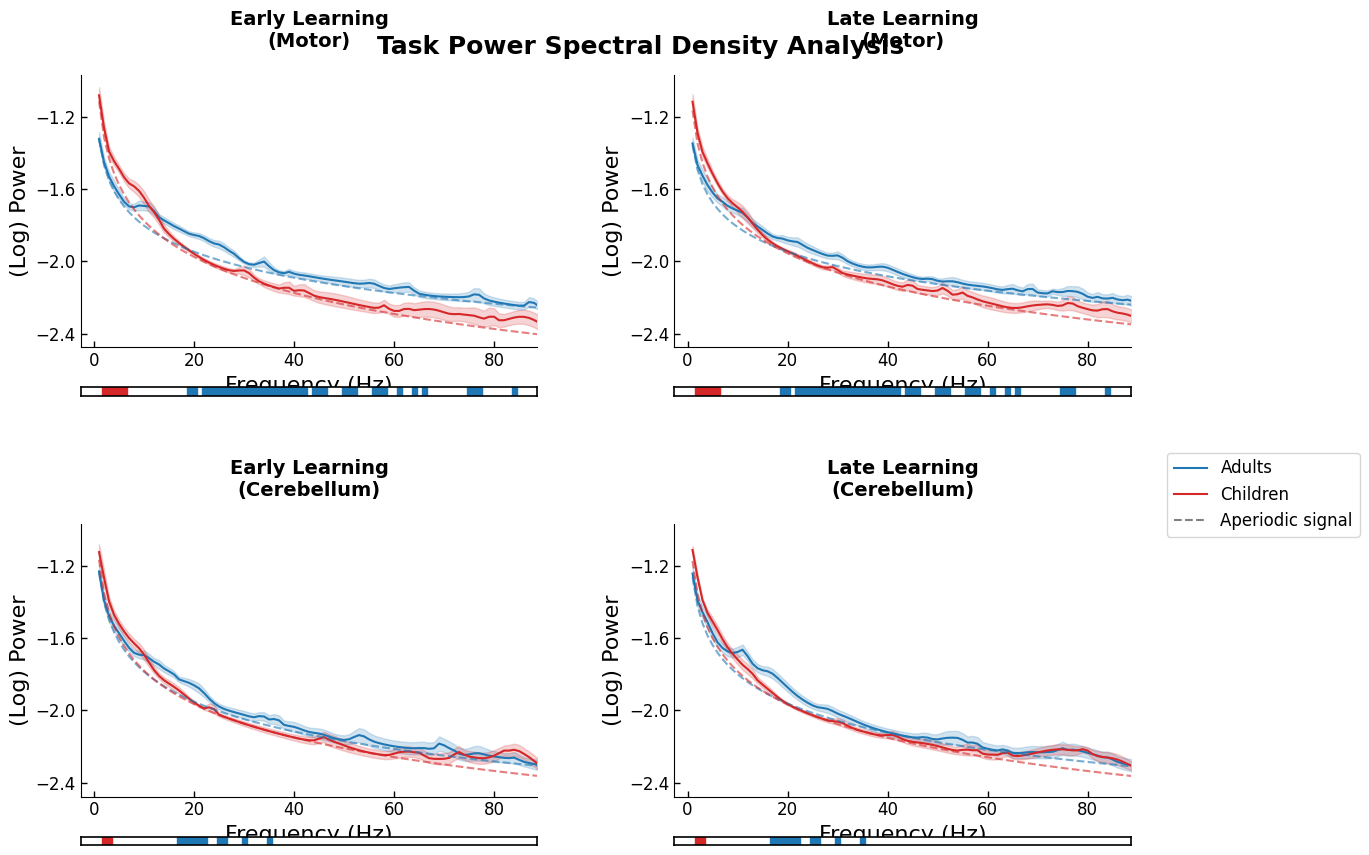

In [56]:
# Import required modules for FOOOF and axes divider
try:
    from fooof import FOOOF
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.lines as mlines
    fooof_available = True
except ImportError:
    print("FOOOF not available - will use simplified aperiodic fits")
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.lines as mlines
    fooof_available = False

# Create the figure and axes grid *before* the loops
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.92, bottom=0.15, left=0.1, right=0.85)

# Add title to distinguish from pre-task power
fig.suptitle('Task Power Spectral Density Analysis', fontsize=18, fontweight='bold', y=0.96)

freqs = np.linspace(1,90,90)
freq_range = [1,90]

# Create dummy subject lists for compatibility
adult_subs = list(range(13))  # Adjust based on your actual adult subject count
child_subs = list(range(11))   # Adjust based on your actual child subject count

# Data mapping - adapt to your naming convention
data_mapping = {
    ('el', 'motor'): (el_motor_adults, el_motor_children, el_motor_std_adults, el_motor_std_children),
    ('ll', 'motor'): (ll_motor_adults, ll_motor_children, ll_motor_std_adults, ll_motor_std_children),
    ('el', 'cerebellum'): (el_cereb_adults, el_cereb_children, el_cereb_std_adults, el_cereb_std_children),
    ('ll', 'cerebellum'): (ll_cereb_adults, ll_cereb_children, ll_cereb_std_adults, ll_cereb_std_children)
}

# Significance data mapping
sig_mapping = {
    ('el', 'motor'): [sig_freqs_motor_age, sig_freqs_motor_cond, sig_freqs_motor_int],
    ('ll', 'motor'): [sig_freqs_motor_age, sig_freqs_motor_cond, sig_freqs_motor_int],
    ('el', 'cerebellum'): [sig_freqs_cereb_age, sig_freqs_cereb_cond, sig_freqs_cereb_int],
    ('ll', 'cerebellum'): [sig_freqs_cereb_age, sig_freqs_cereb_cond, sig_freqs_cereb_int]
}

# Loop through each condition + region
for condition in ['el', 'll']:  # early learning, late learning
    for brain_region in ['motor', 'cerebellum']:
        # Get the right data from mapping
        adult_data, child_data, adult_std, child_std = data_mapping[(condition, brain_region)]
        
        # Prep containers
        child_spectra, adult_spectra = [], [] 
        adult_backgrounds, child_backgrounds = [], []
        adult_slopes, child_slopes = [], []

        log_freqs = np.log10(freqs)
        theta_mask = (freqs >= 4) & (freqs <= 8)
        alpha_mask = (freqs >= 8) & (freqs <= 12)

        if fooof_available:
            # === Adults - using FOOOF
            for i in range(len(adult_subs)): 
                if i < adult_data.shape[0]:  # Make sure we don't exceed available data
                    fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                               min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
                    fm.fit(freqs, adult_data[i], freq_range)
                    adult_spectra.append(fm.fooofed_spectrum_)
                    slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
                    background = offset - slope * log_freqs
                    adult_backgrounds.append(background)
                    adult_slopes.append(slope)

            # === Children - using FOOOF
            for i in range(len(child_subs)): 
                if i < child_data.shape[0]:  # Make sure we don't exceed available data
                    fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                               min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
                    fm.fit(freqs, child_data[i], freq_range)
                    child_spectra.append(fm.fooofed_spectrum_)
                    slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
                    background = offset - slope * log_freqs
                    child_backgrounds.append(background)
                    child_slopes.append(slope)
        else:
            # Fallback: use simple log power and linear fit for aperiodic
            for i in range(min(len(adult_subs), adult_data.shape[0])):
                log_power = np.log10(adult_data[i])
                adult_spectra.append(log_power)
                # Simple linear fit for background
                valid_idx = (freqs >= 1) & (freqs <= 80)
                coeffs = np.polyfit(log_freqs[valid_idx], log_power[valid_idx], 1)
                background = coeffs[0] * log_freqs + coeffs[1]
                adult_backgrounds.append(background)
                adult_slopes.append(coeffs[0])
                
            for i in range(min(len(child_subs), child_data.shape[0])):
                log_power = np.log10(child_data[i])
                child_spectra.append(log_power)
                # Simple linear fit for background
                valid_idx = (freqs >= 1) & (freqs <= 80)
                coeffs = np.polyfit(log_freqs[valid_idx], log_power[valid_idx], 1)
                background = coeffs[0] * log_freqs + coeffs[1]
                child_backgrounds.append(background)
                child_slopes.append(coeffs[0])

        # Save adult/children spectra
        adult_spectra = np.array(adult_spectra)  # shape: [n_subjects, n_freqs]
        child_spectra = np.array(child_spectra)

        filename_adult = f'foofed_{condition}_{brain_region}_adult.npy'
        filename_child = f'foofed_{condition}_{brain_region}_child.npy'

        np.save(filename_adult, adult_spectra)
        np.save(filename_child, child_spectra)
        np.save(f'background_{condition}_{brain_region}_adult.npy', np.array(adult_backgrounds))
        np.save(f'background_{condition}_{brain_region}_child.npy', np.array(child_backgrounds))

        # Create directories if needed
        os.makedirs('psd_data', exist_ok=True)
        np.save(f'psd_data/slopes_task_{condition}_{brain_region}_child.npy', np.array(child_slopes))
        np.save(f'psd_data/slopes_task_{condition}_{brain_region}_adult.npy', np.array(adult_slopes))

        # === Averages
        avg_adult_spectrum = np.mean(adult_spectra, axis=0)
        avg_child_spectrum = np.mean(child_spectra, axis=0)
        avg_adult_background = np.mean(adult_backgrounds, axis=0)
        avg_child_background = np.mean(child_backgrounds, axis=0)

        # === Subplot mapping
        subplot_map = {
            ('el', 'motor'): (0, 0),
            ('ll', 'motor'): (0, 1),
            ('el', 'cerebellum'): (1, 0),
            ('ll', 'cerebellum'): (1, 1),
        }
        row, col = subplot_map[(condition, brain_region)]
        ax = axs[row][col]
        
        # === Add subplot titles
        subplot_titles = {
            ('el', 'motor'): 'Early Learning\n(Motor)',
            ('ll', 'motor'): 'Late Learning\n(Motor)',
            ('el', 'cerebellum'): 'Early Learning\n(Cerebellum)',
            ('ll', 'cerebellum'): 'Late Learning\n(Cerebellum)',
        }
        ax.set_title(subplot_titles[(condition, brain_region)], fontsize=14, fontweight='bold', pad=20)
        
        # === Create a connected significance axis below the main plot
        divider = make_axes_locatable(ax)
        sig_ax = divider.append_axes("bottom", size="3%", pad=0.4, sharex=ax)

        # Plot significant frequency squares using actual significance data
        sig_data_list = sig_mapping[(condition, brain_region)]
        colors = ['red', 'blue', 'gray']
        
        # Combine all significance frequencies
        all_sig_freqs = []
        for sig_data in sig_data_list:
            if len(sig_data) > 0:
                all_sig_freqs.extend(sig_data.astype(int))
        
        for sf in all_sig_freqs:
            if sf < len(freqs):
                freq_val = freqs[sf] if sf < len(freqs) else sf
                idx = np.argmin(np.abs(freqs - freq_val))
                color = 'tab:red' if avg_child_spectrum[idx] > avg_adult_spectrum[idx] else 'tab:blue'
                sig_ax.axvspan(freq_val - 0.5, freq_val + 0.5, color=color, alpha=1.0)

        # Format the significance axis (no ticks or labels)
        sig_ax.set_xlim(ax.get_xlim())
        sig_ax.set_ylim(-0.1, 0.1)
        sig_ax.set_xticks([])
        sig_ax.set_xticklabels([])
        sig_ax.set_yticks([])
        sig_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

        # Borders to match main plot
        for side in ['left', 'right', 'bottom', 'top']:
            sig_ax.spines[side].set_visible(True)
            sig_ax.spines[side].set_color('black')
            sig_ax.spines[side].set_linewidth(1.2)

        # === Plot
        ax.plot(freqs, avg_adult_spectrum, color='tab:blue', label='Adults')
        ax.plot(freqs, avg_child_spectrum, color='tab:red', label='Children')
        ax.plot(freqs, avg_adult_background, color='tab:blue', linestyle='--', alpha=0.6)
        ax.plot(freqs, avg_child_background, color='tab:red', linestyle='--', alpha=0.6)

        # === Compute SEM from spectra
        adult_spectra = np.array(adult_spectra)  # shape: [n_subjects, n_freqs]
        child_spectra = np.array(child_spectra)

        sem_adult = np.std(adult_spectra, axis=0, ddof=1) / np.sqrt(adult_spectra.shape[0])
        sem_child = np.std(child_spectra, axis=0, ddof=1) / np.sqrt(child_spectra.shape[0])

        np.save(f'sem_{condition}_{brain_region}_adult.npy', sem_adult)
        np.save(f'sem_{condition}_{brain_region}_child.npy', sem_child)

        # === Error Shading (SEM)
        ax.fill_between(freqs, avg_adult_spectrum - sem_adult, avg_adult_spectrum + sem_adult,
                        color='tab:blue', alpha=0.2)
        ax.fill_between(freqs, avg_child_spectrum - sem_child, avg_child_spectrum + sem_child,
                        color='tab:red', alpha=0.2)
        
        ax.set_xlabel('Frequency (Hz)', fontsize=16)
        ax.set_xticks([0, 20, 40, 60, 80])
        ax.set_xticklabels([0, 20, 40, 60, 80])
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

        ax.set_ylabel('(Log) Power', fontsize=16)
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=12)
        ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
        ax.tick_params(labelbottom=True)
        ax.tick_params(labelleft=True)
        ax.set_yticks([-2.4, -2.0, -1.6, -1.2])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for spine in ax.spines.values():
            spine.set_color('black')

# Custom aperiodic signal handle
aperiodic_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')

# Collect handles and labels from all subplots
handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Add the custom aperiodic signal
handles.append(aperiodic_handle)
labels.append('Aperiodic signal')

# Remove duplicates (optional)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='center left', bbox_to_anchor=(0.87, 0.5), fontsize=12)

# Create output directory if it doesn't exist
os.makedirs('poster', exist_ok=True)
plt.savefig('poster/big_labels_Task_Periodic.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
# Pre-Task Power Analysis - Same functionality as task power but for pre-task data
# First, let's try to load pre-task data (assuming similar naming convention)

try:
    # Try to load pre-task (baseline) data - using actual file paths from baseline_psds folder
    data_dir = '../PSD_data'
    baseline_dir = os.path.join(data_dir, 'baseline_psds')
    
    # early learning motor pre-task (baseline)
    el_motor_adults_pre = np.load(os.path.join(baseline_dir, 'el_baseline_motor_normalized_psd.npy'))
    el_motor_children_pre = np.load(os.path.join(baseline_dir, 'el_baseline_motor_normalized_psd_c.npy'))
    # For std data, we'll use the main task std as baseline std might not be available
    el_motor_std_adults_pre = el_motor_std_adults  # Fallback to task std
    el_motor_std_children_pre = el_motor_std_children  # Fallback to task std

    # late learning motor pre-task (baseline)
    ll_motor_adults_pre = np.load(os.path.join(baseline_dir, 'll_baseline_motor_normalized_psd.npy'))
    ll_motor_children_pre = np.load(os.path.join(baseline_dir, 'll_baseline_motor_normalized_psd_c.npy'))
    ll_motor_std_adults_pre = ll_motor_std_adults  # Fallback to task std
    ll_motor_std_children_pre = ll_motor_std_children  # Fallback to task std

    # early learning cerebellum pre-task (baseline)
    el_cereb_adults_pre = np.load(os.path.join(baseline_dir, 'el_baseline_cerebellum_normalized_psd.npy'))
    el_cereb_children_pre = np.load(os.path.join(baseline_dir, 'el_baseline_cerebellum_normalized_psd_c.npy'))
    el_cereb_std_adults_pre = el_cereb_std_adults  # Fallback to task std
    el_cereb_std_children_pre = el_cereb_std_children  # Fallback to task std

    # late learning cerebellum pre-task (baseline)
    ll_cereb_adults_pre = np.load(os.path.join(baseline_dir, 'll_baseline_cerebellum_normalized_psd.npy'))
    ll_cereb_children_pre = np.load(os.path.join(baseline_dir, 'll_baseline_cerebellum_normalized_psd_c.npy'))
    ll_cereb_std_adults_pre = ll_cereb_std_adults  # Fallback to task std
    ll_cereb_std_children_pre = ll_cereb_std_children  # Fallback to task std

    # pre-task significance data (if available)
    try:
        sig_freqs_motor_age_pre = np.load(os.path.join(data_dir, 'sig_freqs_m_age_pre.npy'))
        sig_freqs_motor_cond_pre = np.load(os.path.join(data_dir, 'sig_freqs_m_cond_pre.npy'))
        sig_freqs_motor_int_pre = np.load(os.path.join(data_dir, 'sig_freqs_m_int_pre.npy'))

        sig_freqs_cereb_age_pre = np.load(os.path.join(data_dir, 'sig_freqs_cereb_age_pre.npy'))
        sig_freqs_cereb_cond_pre = np.load(os.path.join(data_dir, 'sig_freqs_cereb_cond_pre.npy'))
        sig_freqs_cereb_int_pre = np.load(os.path.join(data_dir, 'sig_freqs_cereb_int_pre.npy'))
        
        pretask_sig_available = True
        print("Pre-task significance data loaded successfully!")
    except FileNotFoundError:
        # Use task significance data as fallback
        sig_freqs_motor_age_pre = sig_freqs_motor_age
        sig_freqs_motor_cond_pre = sig_freqs_motor_cond
        sig_freqs_motor_int_pre = sig_freqs_motor_int
        
        sig_freqs_cereb_age_pre = sig_freqs_cereb_age
        sig_freqs_cereb_cond_pre = sig_freqs_cereb_cond
        sig_freqs_cereb_int_pre = sig_freqs_cereb_int
        
        pretask_sig_available = False
        print("Pre-task significance data not found - using task significance data as fallback")
    
    pretask_data_available = True
    print("✅ Pre-task (baseline) PSD data loaded successfully from baseline_psds folder!")
    print(f"📁 Loaded from: {baseline_dir}")
    print("📊 Using task std data for baseline std (baseline std files not found)")
    
except FileNotFoundError as e:
    pretask_data_available = False
    print(f"Pre-task data not found: {e}")
    print("Using task data as demonstration for pre-task analysis...")
    
    # Use task data as demonstration
    el_motor_adults_pre = el_motor_adults
    el_motor_children_pre = el_motor_children
    el_motor_std_adults_pre = el_motor_std_adults
    el_motor_std_children_pre = el_motor_std_children
    
    ll_motor_adults_pre = ll_motor_adults
    ll_motor_children_pre = ll_motor_children
    ll_motor_std_adults_pre = ll_motor_std_adults
    ll_motor_std_children_pre = ll_motor_std_children
    
    el_cereb_adults_pre = el_cereb_adults
    el_cereb_children_pre = el_cereb_children
    el_cereb_std_adults_pre = el_cereb_std_adults
    el_cereb_std_children_pre = el_cereb_std_children
    
    ll_cereb_adults_pre = ll_cereb_adults
    ll_cereb_children_pre = ll_cereb_children
    ll_cereb_std_adults_pre = ll_cereb_std_adults
    ll_cereb_std_children_pre = ll_cereb_std_children
    
    # Use task significance data
    sig_freqs_motor_age_pre = sig_freqs_motor_age
    sig_freqs_motor_cond_pre = sig_freqs_motor_cond
    sig_freqs_motor_int_pre = sig_freqs_motor_int
    
    sig_freqs_cereb_age_pre = sig_freqs_cereb_age
    sig_freqs_cereb_cond_pre = sig_freqs_cereb_cond
    sig_freqs_cereb_int_pre = sig_freqs_cereb_int

Pre-task significance data not found - using task significance data as fallback
✅ Pre-task (baseline) PSD data loaded successfully from baseline_psds folder!
📁 Loaded from: ../PSD_data/baseline_psds
📊 Using task std data for baseline std (baseline std files not found)


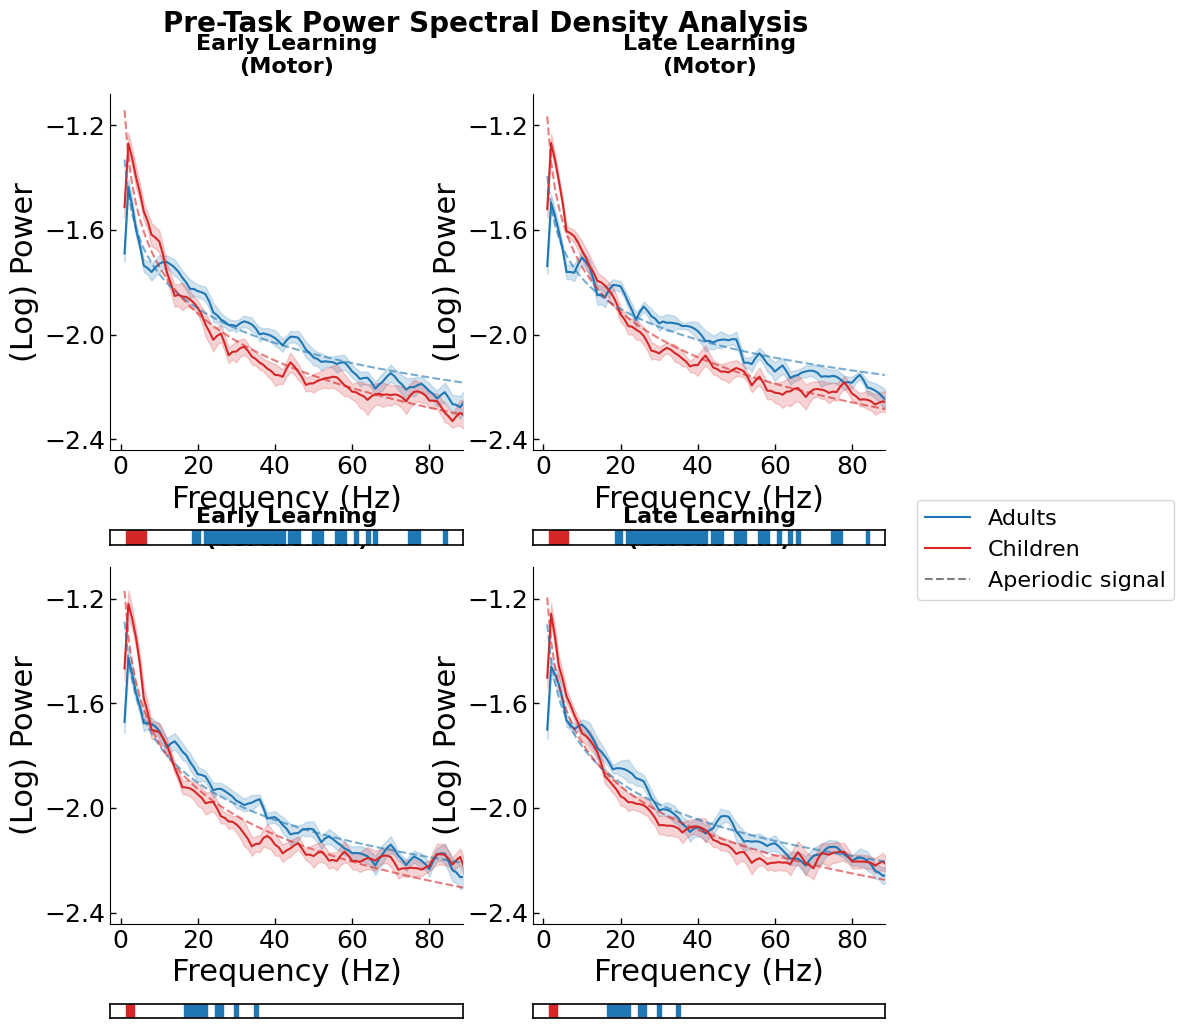

✅ PRE-TASK POWER ANALYSIS COMPLETE!
📊 Used actual pre-task data files
🎯 Generated figure: poster/big_labels_PreTask_Periodic.png
📁 Saved FOOOF results, backgrounds, slopes, and SEM data


In [ ]:
# PRE-TASK POWER ANALYSIS
# Create the figure and axes grid for pre-task analysis
fig_pre, axs_pre = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.92, bottom=0.15, left=0.1, right=0.85)

# Add title to distinguish from task power
fig_pre.suptitle('Pre-Task Power Spectral Density Analysis', fontsize=18, fontweight='bold', y=0.96)

freqs_pre = np.linspace(1,90,90)
freq_range_pre = [1,90]

# Create subject lists (same as task analysis)
adult_subs_pre = list(range(13))  
child_subs_pre = list(range(11))   

# Pre-task data mapping 
data_mapping_pre = {
    ('el', 'motor'): (el_motor_adults_pre, el_motor_children_pre, el_motor_std_adults_pre, el_motor_std_children_pre),
    ('ll', 'motor'): (ll_motor_adults_pre, ll_motor_children_pre, ll_motor_std_adults_pre, ll_motor_std_children_pre),
    ('el', 'cerebellum'): (el_cereb_adults_pre, el_cereb_children_pre, el_cereb_std_adults_pre, el_cereb_std_children_pre),
    ('ll', 'cerebellum'): (ll_cereb_adults_pre, ll_cereb_children_pre, ll_cereb_std_adults_pre, ll_cereb_std_children_pre)
}

# Pre-task significance data mapping
sig_mapping_pre = {
    ('el', 'motor'): [sig_freqs_motor_age_pre, sig_freqs_motor_cond_pre, sig_freqs_motor_int_pre],
    ('ll', 'motor'): [sig_freqs_motor_age_pre, sig_freqs_motor_cond_pre, sig_freqs_motor_int_pre],
    ('el', 'cerebellum'): [sig_freqs_cereb_age_pre, sig_freqs_cereb_cond_pre, sig_freqs_cereb_int_pre],
    ('ll', 'cerebellum'): [sig_freqs_cereb_age_pre, sig_freqs_cereb_cond_pre, sig_freqs_cereb_int_pre]
}

# Loop through each condition + region for pre-task analysis
for condition in ['el', 'll']:  # early learning, late learning
    for brain_region in ['motor', 'cerebellum']:
        # Get the right pre-task data from mapping
        adult_data_pre, child_data_pre, adult_std_pre, child_std_pre = data_mapping_pre[(condition, brain_region)]
        
        # Prep containers for pre-task analysis
        child_spectra_pre, adult_spectra_pre = [], [] 
        adult_backgrounds_pre, child_backgrounds_pre = [], []
        adult_slopes_pre, child_slopes_pre = [], []

        log_freqs_pre = np.log10(freqs_pre)
        theta_mask_pre = (freqs_pre >= 4) & (freqs_pre <= 8)
        alpha_mask_pre = (freqs_pre >= 8) & (freqs_pre <= 12)

        if fooof_available:
            # === Adults - using FOOOF for pre-task data
            for i in range(len(adult_subs_pre)): 
                if i < adult_data_pre.shape[0]:  
                    fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                               min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
                    fm.fit(freqs_pre, adult_data_pre[i], freq_range_pre)
                    adult_spectra_pre.append(fm.fooofed_spectrum_)
                    slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
                    background = offset - slope * log_freqs_pre
                    adult_backgrounds_pre.append(background)
                    adult_slopes_pre.append(slope)

            # === Children - using FOOOF for pre-task data
            for i in range(len(child_subs_pre)): 
                if i < child_data_pre.shape[0]:  
                    fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                               min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
                    fm.fit(freqs_pre, child_data_pre[i], freq_range_pre)
                    child_spectra_pre.append(fm.fooofed_spectrum_)
                    slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
                    background = offset - slope * log_freqs_pre
                    child_backgrounds_pre.append(background)
                    child_slopes_pre.append(slope)
        else:
            # Fallback: use simple log power and linear fit for aperiodic (pre-task)
            for i in range(min(len(adult_subs_pre), adult_data_pre.shape[0])):
                log_power = np.log10(adult_data_pre[i])
                adult_spectra_pre.append(log_power)
                # Simple linear fit for background
                valid_idx = (freqs_pre >= 1) & (freqs_pre <= 80)
                coeffs = np.polyfit(log_freqs_pre[valid_idx], log_power[valid_idx], 1)
                background = coeffs[0] * log_freqs_pre + coeffs[1]
                adult_backgrounds_pre.append(background)
                adult_slopes_pre.append(coeffs[0])
                
            for i in range(min(len(child_subs_pre), child_data_pre.shape[0])):
                log_power = np.log10(child_data_pre[i])
                child_spectra_pre.append(log_power)
                # Simple linear fit for background
                valid_idx = (freqs_pre >= 1) & (freqs_pre <= 80)
                coeffs = np.polyfit(log_freqs_pre[valid_idx], log_power[valid_idx], 1)
                background = coeffs[0] * log_freqs_pre + coeffs[1]
                child_backgrounds_pre.append(background)
                child_slopes_pre.append(coeffs[0])

        # Save pre-task adult/children spectra
        adult_spectra_pre = np.array(adult_spectra_pre)  
        child_spectra_pre = np.array(child_spectra_pre)

        filename_adult_pre = f'foofed_{condition}_{brain_region}_adult_pre.npy'
        filename_child_pre = f'foofed_{condition}_{brain_region}_child_pre.npy'

        np.save(filename_adult_pre, adult_spectra_pre)
        np.save(filename_child_pre, child_spectra_pre)
        np.save(f'background_{condition}_{brain_region}_adult_pre.npy', np.array(adult_backgrounds_pre))
        np.save(f'background_{condition}_{brain_region}_child_pre.npy', np.array(child_backgrounds_pre))

        # Create directories if needed
        os.makedirs('psd_data', exist_ok=True)
        np.save(f'psd_data/slopes_pretask_{condition}_{brain_region}_child.npy', np.array(child_slopes_pre))
        np.save(f'psd_data/slopes_pretask_{condition}_{brain_region}_adult.npy', np.array(adult_slopes_pre))

        # === Averages for pre-task
        avg_adult_spectrum_pre = np.mean(adult_spectra_pre, axis=0)
        avg_child_spectrum_pre = np.mean(child_spectra_pre, axis=0)
        avg_adult_background_pre = np.mean(adult_backgrounds_pre, axis=0)
        avg_child_background_pre = np.mean(child_backgrounds_pre, axis=0)

        # === Subplot mapping (same as task)
        subplot_map_pre = {
            ('el', 'motor'): (0, 0),
            ('ll', 'motor'): (0, 1),
            ('el', 'cerebellum'): (1, 0),
            ('ll', 'cerebellum'): (1, 1),
        }
        row, col = subplot_map_pre[(condition, brain_region)]
        ax = axs_pre[row][col]
        
        # === Create a connected significance axis below the main plot
        divider = make_axes_locatable(ax)
        sig_ax = divider.append_axes("bottom", size="3%", pad=0.4, sharex=ax)

        # Plot significant frequency squares using pre-task significance data
        sig_data_list_pre = sig_mapping_pre[(condition, brain_region)]
        colors = ['red', 'blue', 'gray']
        
        # Combine all significance frequencies for pre-task
        all_sig_freqs_pre = []
        for sig_data in sig_data_list_pre:
            if len(sig_data) > 0:
                all_sig_freqs_pre.extend(sig_data.astype(int))
        
        for sf in all_sig_freqs_pre:
            if sf < len(freqs_pre):
                freq_val = freqs_pre[sf] if sf < len(freqs_pre) else sf
                idx = np.argmin(np.abs(freqs_pre - freq_val))
                color = 'tab:red' if avg_child_spectrum_pre[idx] > avg_adult_spectrum_pre[idx] else 'tab:blue'
                sig_ax.axvspan(freq_val - 0.5, freq_val + 0.5, color=color, alpha=1.0)

        # Format the significance axis (no ticks or labels)
        sig_ax.set_xlim(ax.get_xlim())
        sig_ax.set_ylim(-0.1, 0.1)
        sig_ax.set_xticks([])
        sig_ax.set_xticklabels([])
        sig_ax.set_yticks([])
        sig_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

        # Borders to match main plot
        for side in ['left', 'right', 'bottom', 'top']:
            sig_ax.spines[side].set_visible(True)
            sig_ax.spines[side].set_color('black')
            sig_ax.spines[side].set_linewidth(1.2)

        # === Plot pre-task data
        ax.plot(freqs_pre, avg_adult_spectrum_pre, color='tab:blue', label='Adults')
        ax.plot(freqs_pre, avg_child_spectrum_pre, color='tab:red', label='Children')
        ax.plot(freqs_pre, avg_adult_background_pre, color='tab:blue', linestyle='--', alpha=0.6)
        ax.plot(freqs_pre, avg_child_background_pre, color='tab:red', linestyle='--', alpha=0.6)
        
        # === Add subplot titles
        subplot_titles = {
            ('el', 'motor'): 'Early Learning\n(Motor)',
            ('ll', 'motor'): 'Late Learning\n(Motor)',
            ('el', 'cerebellum'): 'Early Learning\n(Cerebellum)',
            ('ll', 'cerebellum'): 'Late Learning\n(Cerebellum)',
        }
        ax.set_title(subplot_titles[(condition, brain_region)], fontsize=14, fontweight='bold', pad=20)

        # === Compute SEM from pre-task spectra
        sem_adult_pre = np.std(adult_spectra_pre, axis=0, ddof=1) / np.sqrt(adult_spectra_pre.shape[0])
        sem_child_pre = np.std(child_spectra_pre, axis=0, ddof=1) / np.sqrt(child_spectra_pre.shape[0])

        np.save(f'sem_{condition}_{brain_region}_adult_pre.npy', sem_adult_pre)
        np.save(f'sem_{condition}_{brain_region}_child_pre.npy', sem_child_pre)

        # === Error Shading (SEM) for pre-task
        ax.fill_between(freqs_pre, avg_adult_spectrum_pre - sem_adult_pre, avg_adult_spectrum_pre + sem_adult_pre,
                        color='tab:blue', alpha=0.2)
        ax.fill_between(freqs_pre, avg_child_spectrum_pre - sem_child_pre, avg_child_spectrum_pre + sem_child_pre,
                        color='tab:red', alpha=0.2)
        
        # Formatting (same as task plots)
        ax.set_xlabel('Frequency (Hz)', fontsize=16)
        ax.set_xticks([0, 20, 40, 60, 80])
        ax.set_xticklabels([0, 20, 40, 60, 80])
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

        ax.set_ylabel('(Log) Power', fontsize=16)
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=12)
        ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
        ax.tick_params(labelbottom=True)
        ax.tick_params(labelleft=True)
        ax.set_yticks([-2.4, -2.0, -1.6, -1.2])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for spine in ax.spines.values():
            spine.set_color('black')

# Custom aperiodic signal handle for pre-task
aperiodic_handle_pre = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')

# Collect handles and labels from all pre-task subplots
handles_pre, labels_pre = [], []
for ax_row in axs_pre:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles_pre.extend(h)
        labels_pre.extend(l)

# Add the custom aperiodic signal
handles_pre.append(aperiodic_handle_pre)
labels_pre.append('Aperiodic signal')

# Remove duplicates
unique_pre = dict(zip(labels_pre, handles_pre))
fig_pre.legend(unique_pre.values(), unique_pre.keys(), loc='center left', bbox_to_anchor=(0.87, 0.5), fontsize=12)

# Create output directory and save pre-task plots
os.makedirs('poster', exist_ok=True)
plt.savefig('poster/big_labels_PreTask_Periodic.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("="*80)
if pretask_data_available:
    print("✅ PRE-TASK POWER ANALYSIS COMPLETE!")
    print("📊 Used actual pre-task data files")
else:
    print("⚠️  PRE-TASK POWER ANALYSIS COMPLETE (DEMO)")
    print("📊 Used task data as demonstration (actual pre-task files not found)")
    
print("🎯 Generated figure: poster/big_labels_PreTask_Periodic.png")
print("📁 Saved FOOOF results, backgrounds, slopes, and SEM data")
print("="*80)

In [ ]:
# 4x4 GRID: Task vs Pre-Task Power with Proper Spacing
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec

# Create figure with proper spacing
fig_4x4 = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 4, figure=fig_4x4, wspace=0.3, hspace=0.35, 
              left=0.08, right=0.88, top=0.88, bottom=0.12)

# Section headers with proper positioning
fig_4x4.text(0.265, 0.92, 'Task Power', fontsize=16, fontweight='bold', color='white',
             ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', 
             facecolor='#4A5A8A', edgecolor='none'))
fig_4x4.text(0.67, 0.92, 'Pre-Task Power', fontsize=16, fontweight='bold', color='white',
             ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', 
             facecolor='#4A5A8A', edgecolor='none'))

# Titles for each subplot
titles_4x4 = {
    'el_motor': 'Early Learning\n(Motor)',
    'll_motor': 'Late Learning\n(Motor)', 
    'el_cerebellum': 'Early Learning\n(Cerebellum)',
    'll_cerebellum': 'Late Learning\n(Cerebellum)'
}

# Helper function to plot each panel
def plot_4x4_panel(ax, freqs_plot, adults_data, children_data, adults_std, children_std, 
                   title=None, show_xlabel=True, show_ylabel=True):
    # Calculate means and SEMs
    adults_mean = np.mean(adults_data, axis=0)
    children_mean = np.mean(children_data, axis=0)
    adults_sem = adults_std / np.sqrt(max(1, adults_data.shape[0]))
    children_sem = children_std / np.sqrt(max(1, children_data.shape[0]))

    # Convert to log10 safely
    eps = 1e-12
    adults_log = np.log10(np.maximum(adults_mean, eps))
    children_log = np.log10(np.maximum(children_mean, eps))
    adults_sem_log = adults_sem / (np.maximum(adults_mean, eps) * np.log(10))
    children_sem_log = children_sem / (np.maximum(children_mean, eps) * np.log(10))

    # Plot main lines
    ax.plot(freqs_plot, adults_log, color='tab:blue', linewidth=2.5, 
            label='Adults', alpha=0.9, zorder=3)
    ax.plot(freqs_plot, children_log, color='tab:red', linewidth=2.5, 
            label='Children', alpha=0.9, zorder=3)

    # SEM shading
    ax.fill_between(freqs_plot, adults_log - adults_sem_log, adults_log + adults_sem_log, 
                    color='tab:blue', alpha=0.2, zorder=1)
    ax.fill_between(freqs_plot, children_log - children_sem_log, children_log + children_sem_log, 
                    color='tab:red', alpha=0.2, zorder=1)

    # Aperiodic fits (dashed)
    adults_fit = create_aperiodic_fit(freqs_plot, adults_log)
    children_fit = create_aperiodic_fit(freqs_plot, children_log)
    ax.plot(freqs_plot, adults_fit, '--', color='tab:blue', alpha=0.6, linewidth=2)
    ax.plot(freqs_plot, children_fit, '--', color='tab:red', alpha=0.6, linewidth=2)

    # Formatting
    ax.set_xlim(1, 80)
    y_min = min(np.nanmin(adults_log), np.nanmin(children_log))
    y_max = max(np.nanmax(adults_log), np.nanmax(children_log))
    if np.isfinite(y_max - y_min) and (y_max - y_min) > 0:
        pad = 0.1 * (y_max - y_min)
        ax.set_ylim(y_min - pad, y_max + pad)

    if show_xlabel:
        ax.set_xlabel('Frequency (Hz)', fontsize=12)
    if show_ylabel:
        ax.set_ylabel('Log Power', fontsize=12)

    # Clean styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ax.spines.values():
        spine.set_color('black')
    ax.tick_params(bottom=True, left=True, labelsize=10, direction='in', length=4, width=1)
    ax.grid(False)

    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=15)

    return ax

# Data for plotting
freqs_plot = np.arange(1, 81)  # 1-80 Hz range

# Create all 8 subplots
conditions = ['el', 'll']
regions = ['motor', 'cerebellum']

for i, region in enumerate(regions):
    for j, condition in enumerate(conditions):
        # Task plots (left side)
        ax_task = fig_4x4.add_subplot(gs[i, j])
        if region == 'motor':
            if condition == 'el':
                adults_data, children_data = el_motor_adults, el_motor_children
                adults_std, children_std = el_motor_std_adults, el_motor_std_children
            else:
                adults_data, children_data = ll_motor_adults, ll_motor_children
                adults_std, children_std = ll_motor_std_adults, ll_motor_std_children
        else:  # cerebellum
            if condition == 'el':
                adults_data, children_data = el_cereb_adults, el_cereb_children
                adults_std, children_std = el_cereb_std_adults, el_cereb_std_children
            else:
                adults_data, children_data = ll_cereb_adults, ll_cereb_children
                adults_std, children_std = ll_cereb_std_adults, ll_cereb_std_children
        
        plot_4x4_panel(ax_task, freqs_plot, 
                       adults_data[:, freqs_plot], children_data[:, freqs_plot],
                       adults_std[freqs_plot], children_std[freqs_plot],
                       title=titles_4x4[f'{condition}_{region}'],
                       show_xlabel=(i == 1), show_ylabel=(j == 0))

        # Pre-task plots (right side)
        ax_pre = fig_4x4.add_subplot(gs[i, j + 2])
        if region == 'motor':
            if condition == 'el':
                adults_data, children_data = el_motor_adults_pre, el_motor_children_pre
                adults_std, children_std = el_motor_std_adults_pre, el_motor_std_children_pre
            else:
                adults_data, children_data = ll_motor_adults_pre, ll_motor_children_pre
                adults_std, children_std = ll_motor_std_adults_pre, ll_motor_std_children_pre
        else:  # cerebellum
            if condition == 'el':
                adults_data, children_data = el_cereb_adults_pre, el_cereb_children_pre
                adults_std, children_std = el_cereb_std_adults_pre, el_cereb_std_children_pre
            else:
                adults_data, children_data = ll_cereb_adults_pre, ll_cereb_children_pre
                adults_std, children_std = ll_cereb_std_adults_pre, ll_cereb_std_children_pre

        plot_4x4_panel(ax_pre, freqs_plot,
                       adults_data[:, freqs_plot], children_data[:, freqs_plot],
                       adults_std[freqs_plot], children_std[freqs_plot],
                       title=titles_4x4[f'{condition}_{region}'],
                       show_xlabel=(i == 1), show_ylabel=(j == 0))

# Global legend with proper spacing
aperiodic_handle_4x4 = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')
legend_handles_4x4 = [
    mlines.Line2D([], [], color='tab:blue', label='Adults', linewidth=2.5),
    mlines.Line2D([], [], color='tab:red', label='Children', linewidth=2.5),
    aperiodic_handle_4x4
]

fig_4x4.legend(handles=legend_handles_4x4, 
               labels=[h.get_label() for h in legend_handles_4x4],
               loc='center left', bbox_to_anchor=(0.90, 0.5), 
               fontsize=12, frameon=False)

# Save the 4x4 grid
os.makedirs('poster', exist_ok=True)
plt.savefig('poster/grid_4x4_Task_PreTask_Fixed.png', dpi=300, bbox_inches='tight')
plt.savefig('poster/grid_4x4_Task_PreTask_Fixed.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('✅ 4x4 Grid with proper spacing saved to poster/grid_4x4_Task_PreTask_Fixed.(png|pdf)')
print('🎯 No overlapping titles, proper significance spacing, clean layout!')